<b>¡Hola Luis!</b>

Mi nombre es Alejandro Abia y tengo el gusto de revisar tu proyecto.

A continuación, encontrarás mis comentarios en celdas pintadas de tres colores (verde, amarillo y rojo), a manera de semáforo. Por favor, <b>no las borres ni muevas de posición</b> mientras dure el proceso de revisión.

<div class="alert alert-block alert-success">
<b>Éxito</b> <a class="tocSkip"></a>
En celdas verdes encontrarás comentarios en relación a tus aciertos y fortalezas.
</div>
<div class="alert alert-block alert-warning">
<b>Antención</b> <a class="tocSkip"></a>
Utilizaré el color amarillo para llamar tu atención, expresar algo importante o compartirte alguna idea de valor.
</div>
<div class="alert alert-block alert-danger">
<b>A resolver</b> <a class="tocSkip"></a>
En rojo emitiré aquellos puntos que deberás atender para aprobar la revisión.
</div>
<div class="alert alert-block alert-info">
<b>Comentario estudiante</b><a class="tocSkip"></a>
Es factible que, a lo largo del proceso de revisión, quieras dejarme comentarios. Si es el caso, por favor realízalo dentro de celdas azules como esta.
</div>
Respecto del proceso de revisión, tu proyecto será aceptado una vez que los comentarios en rojo hayan sido atendidos.
¡Empecemos!

## TIENDA ONLINE ICE- Proyecto 6

Es una tienda de videojuegos online que vende por todo el mundo. 

El objetivo del proyecto es responder algunas preguntas planteadas por la empresa como: 
- Determinar si un juego tiene exito o no. 

Con el objetivo podemos identificar y planificar las campañas de publicidad en base a los datos obtenidos. 

### Paso 1- Abrir y cargar el archivo y estudiar la informacion general

In [1]:
#1.1 Cargar librerias para guardar el df 
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats as st
import math
import seaborn as sns


In [2]:
#cargar el dataset- Se cargo en el repositorio que cree en github
df_games = pd.read_csv("https://raw.githubusercontent.com/LuisPeza/Sprint_6/refs/heads/main/proyecto_s6/df_games.csv",sep= ",")

In [3]:
#Vamos a darle un vistazo a la informacion del dataset usamos info()
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


### Anotaciones de la primera impresión del data
- Se ve de entrada que los nombres de las columnas estan en mayusculas y minusculas, vamos a cambiarlas a minusculas
- Vamos a cambiar los tipos de datos de la columna User_Score a float y el de la columna Year a int

In [4]:
#Revisamos si existen valores perdidos en el df
df_games.isna().sum()

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sales              0
Other_sales           0
Critic_Score       8578
User_Score         6701
Rating             6766
dtype: int64

- Vemos que existen valores perdidos en la columna Year, Critic,User_score, Name y Genre
- Para los valores perdidos de la columna Year los vamos a eliminar ya que son pocos valores

In [5]:
#Visualizamos la informacion general del data con sample() para conocer la informacion que contiene
df_games.sample(10)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
13872,WSC Real 11: World Snooker Championship,X360,2011.0,Sports,0.00,0.03,0.00,0.00,NaN,NaN,NaN
6874,The Adventures of Tintin: The Game,X360,2011.0,Action,0.07,0.13,0.00,0.03,63.0,6.1,E10+
12538,JoJo's Bizarre Adventure: All Star Battle,3DS,2012.0,Fighting,0.06,0.00,0.00,0.00,NaN,NaN,NaN
10640,International Superstar Soccer 64 (weekly JP s...,N64,1997.0,Sports,0.00,0.00,0.05,0.05,NaN,NaN,NaN
1184,Conflict: Desert Storm,PS2,2002.0,Shooter,0.98,0.53,0.00,0.06,55.0,8.6,T
4091,MotorStorm: Apocalypse,PS3,2011.0,Racing,0.21,0.19,0.00,0.08,77.0,7.7,T
4411,Gundam SEED: Federation vs. Z.A.F.T.,PS2,2005.0,Shooter,0.00,0.00,0.44,0.00,NaN,NaN,NaN
7027,Dynasty Warriors: Strikeforce,X360,2009.0,Action,0.13,0.06,0.02,0.02,59.0,5.7,T
5148,Naruto Shippuden: Ninja Destiny 2,DS,2008.0,Fighting,0.19,0.02,0.13,0.02,55.0,5.7,T
13115,R.B.I. Baseball 2016,XOne,2016.0,Sports,0.05,0.00,0.00,0.01,NaN,NaN,NaN


- Viendo los datos se ve que los datos de la columna Name igual vienen en mayusculas y minusculas y algunos signos de deseparación entre palabras vamos a quitarlas

In [6]:
#Vemos los valores unicos de la columna Platform y contamos cuantos valores son
print(df_games['Platform'].unique())

df_games['Platform'].nunique()

['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' 'PS4' '3DS' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'XOne' 'WiiU' 'GC' 'GEN' 'DC' 'PSV' 'SAT'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']


31

- Vemos que tenemos 31 plataformas de video juegos
- Podemos agrupar los juegos con para reducir el numero de plataformas

In [7]:
#Detalle de la columna Year
df_games['Year_of_Release'].unique()

array([2006., 1985., 2008., 2009., 1996., 1989., 1984., 2005., 1999.,
       2007., 2010., 2013., 2004., 1990., 1988., 2002., 2001., 2011.,
       1998., 2015., 2012., 2014., 1992., 1997., 1993., 1994., 1982.,
       2016., 2003., 1986., 2000.,   nan, 1995., 1991., 1981., 1987.,
       1980., 1983.])

- Vemos que los datos de la columna Year_of_Release, contiene valores nulos y esta como tipo de dato float

In [8]:
#Detalle de generos contamos los valores unicos de los juegos por genero
df_games['Genre'].value_counts()

Action          3369
Sports          2348
Misc            1750
Role-Playing    1498
Shooter         1323
Adventure       1303
Racing          1249
Platform         888
Simulation       873
Fighting         849
Strategy         683
Puzzle           580
Name: Genre, dtype: int64

- Notamos 12 diferentes generos de video juegos, la gran mayoria son de Action y Sport

In [9]:
df_games['Critic_Score'].unique()

array([76., nan, 82., 80., 89., 58., 87., 91., 61., 97., 95., 77., 88.,
       83., 94., 93., 85., 86., 98., 96., 90., 84., 73., 74., 78., 92.,
       71., 72., 68., 62., 49., 67., 81., 66., 56., 79., 70., 59., 64.,
       75., 60., 63., 69., 50., 25., 42., 44., 55., 48., 57., 29., 47.,
       65., 54., 20., 53., 37., 38., 33., 52., 30., 32., 43., 45., 51.,
       40., 46., 39., 34., 35., 41., 36., 28., 31., 27., 26., 19., 23.,
       24., 21., 17., 22., 13.])

- Echamos un vistazo a la columna critic_score, vemos que van del 0 al 100 y tiene valores nulos

In [10]:
df_games['User_Score'].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

- Vemos que los valores del puntuacion de los usuarios va de 1 a 10 a diferencia que la de los criticos, vamos a ponerlos de 0 100 tambien.

## Procesamiento de datos 

Ya revisando los datos del dataset comenzamos a preparar y pulir los datos.
Se observa que el nombre de las columnas estan en mayusculas y minisculas. Y que algunos tipos de datos de las columnas estan erroneos vamos corregirlos.

### Reemplazamos los nombres de las columnas(ponemos en minuculas)

In [11]:
#usamos un for para cambiar a minusculas dentro de las columnas del de df
df_games.columns = [x.lower() for x in df_games.columns]

In [12]:
#vemos si se cambiaron a minusculas
df_games.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

In [13]:
#Le ponemos snake cases a la columna name
#cambios a minusculas el nombre de los juegos  
df_games['name'] = df_games['name'].str.lower()
#Quitamos puntos o comas
df_games['name'] = df_games['name'].str.replace(".","").replace(",","")


### Convierte los datos en los tipos necesarios

In [14]:
#Cambiar el caso de tbd por un valor numerico perdido con np.nan
df_games.loc[df_games['user_score']== 'tbd','user_score'] = np.nan

In [15]:
#vamos a cambiar el tipo de datos a float y lo multiplicamos por 10 para que este homogeneo con los datos de critic_score
df_games['user_score'] = df_games['user_score'].astype(float)*10

In [16]:
#vamos a eliminar los valores perdidos de year of ya que representa el 2 % de los datos
df_games= df_games.dropna(subset= ['year_of_release'])

In [17]:
#Vamos a convertir el tipo de dato de la columna year_of_release a int
df_games['year_of_release'] = df_games['year_of_release'].astype(int)

### Describe las columnas en las que los tipos de datos han sido cambiados y explica por qué.

1.- Se cambio el tipo de datos de la columna user_score ya que estaba como object por la salida que tenia de tbd y se convierte a float para que tenga el mismo tipo de datos que critic_score y tengamos los datos homogenos, tambien se le multiplica por 10 para igual vaya del 0 100 en vez del 1 al 10
2.- Se cambia el tipo de datos de la columna year_of_release ya que esta estaba como tipo de datos float y no es muy util dejarla con ese tipo de cambia a int, tambien se eliminan los valores ausentes de esta columna ya que solo son el 2% de los datos no nos afectara mucho en los calculos posteriores ya que sin esto no podia convertir el valor a int. 

### Si es necesario, elige la manera de tratar los valores ausentes.

#### Explica por qué rellenaste los valores ausentes como lo hiciste o por qué decidiste dejarlos en blanco.

In [18]:
#vamos a renombrar esos valors perdidos por no_definido
df_games['genre'] = df_games['genre'].fillna('no_definido')

In [19]:
#vamos a renombrar esos valors perdidos por no_definido
df_games['name'] = df_games['name'].fillna('no_definido')

1.- Los valores ausentes de la columna year_of_release, los elimine ya que solo eran el 2 % del total de los datos y tambien para convertir mis valores a int.
2.- Los valores ausentes de la columna name y genre, se sustituyen con el comentario "no_definido" ya eran son solo 2 datos de cada uno, los pudiera tambien eliminado. 
3.- Los valores ausentes de critic_score, user_score y rating se dejaron ya que estos valores por alguna razon no se encuentran puede que no tengan calificacion o el rating no se les ha asignado.


#### ¿Por qué crees que los valores estan ausentes?. Brinda explicaciones posibles.

1.- Los valores ausentes de la columna year, pudieron olvidar colocarlos o hubo un error al momento de cargar ese dataset
2.- De los valores ausentes de name y genre como solo son 2 valores, igua se les pudo olvidar ponerlos o no encuentraron el genero de esos juegos y el nombre.
3.- Los valores ausentes de critic_user y user_score son muchos en ambos casos con 8578 y 6701, puede que esos juegos no fueron tan relevantes en sus ventas o simplemente no era necesario darles una calificacion ya que eran juegos insignificantes. De la columna de Rating donde se almacena la clasificacion del juego si es para niños, adolesentes y adultos tenemos que son 6766, puede ser que algunos juegos como son recientes todavia no cuenta con esa certificacion de clasificacion de juegos.

#### Presta atención a la abreviatura TDB. Significa "to be determined"(a determinar). Especifica como puedes manejar esto.

- Se cambiaron estos valores de "tdb" por valores perdidos NAN, ya que como aun no tienen una clasificacion no los necesitaremos para el analisis posterior. 

### Calcula las ventas totales(La suma de las ventas en todas las regiones). Para cada juego y coloca estos valores en una columna separada. 

In [20]:
#Creamos una nueva columna llamada ventas_totales con la suma de las ventas de las 4 columnas na_sales,eu_sales,jp_sales y other_sales
df_games['ventas_totales'] =  df_games['na_sales'] + df_games['eu_sales']+ df_games['jp_sales'] + df_games['other_sales']
df_games['ventas_totales'] = round(df_games['ventas_totales'],2)

<div class="alert alert-block alert-success">
<b>Celdas [1–20]</b> <a class="tocSkip"></a><br>
Excelente trabajo en la carga, inspección y procesamiento inicial de los datos. Se detectaron correctamente valores nulos, se aplicaron transformaciones pertinentes como convertir puntuaciones de usuario a escala 0–100, y se justificó adecuadamente cada decisión de limpieza. También se utilizaron expresiones claras para explicar el razonamiento detrás de los cambios, lo cual demuestra muy buena comprensión del flujo de preprocesamiento.
</div>


### Cambios adicionales que se aplicaron a las columnas y se trataron los valores duplicados 

- Agrupamos los nombres de las plataformas ya que son muchas y solo tendremos 5 grandes grupos

In [21]:
#Agrupamos los nombres de las columnas
#Hacemos una funcion para  agrupar
def agrupar_plat (x):
    if x in ['Wii','GB','GC','DS','WiiU','NES','SNES','GBA','3DS','N64']:
        return 'nintendo'
    elif x in ['X360','XB','XOne']:
        return 'xbox'
    elif x in ['PS3','PS2','PS','PSP','PS4','PSV']:
        return 'play'
    elif x in ['PC','PCFX']:
        return 'pc'
    else:
        return 'otros'

In [22]:
#Aplicamos la funcion para crear la columna agrupacion
df_games['group_plat'] = df_games['platform'].apply(agrupar_plat)

In [23]:
#Revisar si hay duplicados 
df_games[df_games[['name','platform','year_of_release']].duplicated()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,ventas_totales,group_plat
14244,no_definido,GEN,1993,no_definido,0.0,0.00,0.03,0.0,NaN,NaN,NaN,0.03,otros
16230,madden nfl 13,PS3,2012,Sports,0.0,0.01,0.00,0.0,83.0,55.0,E,0.01,play


In [24]:
#Eliminamos duplicados con dropduplicates y subset
df_games = df_games.drop_duplicates(subset= ['name','platform','year_of_release']).reset_index(drop=True)

<div class="alert alert-block alert-success">
<b>Celdas [21–24]</b> <a class="tocSkip"></a><br>
Muy buena decisión al agrupar las plataformas en grandes categorías. Esto facilita significativamente el análisis posterior y reduce la fragmentación de datos. Además, la eliminación de duplicados con subset relevante es una acción precisa y necesaria para evitar distorsiones.
</div>


## Analisis de datos

### Mira cuantos juegos fueron lanzados en diferentes años. ¿Son significativos los datos de cada periodo.?.

In [25]:
#Agrupamos por año y contamos el numero de juegos por año.
juegos_lanzados = df_games.groupby('year_of_release')['name'].count()

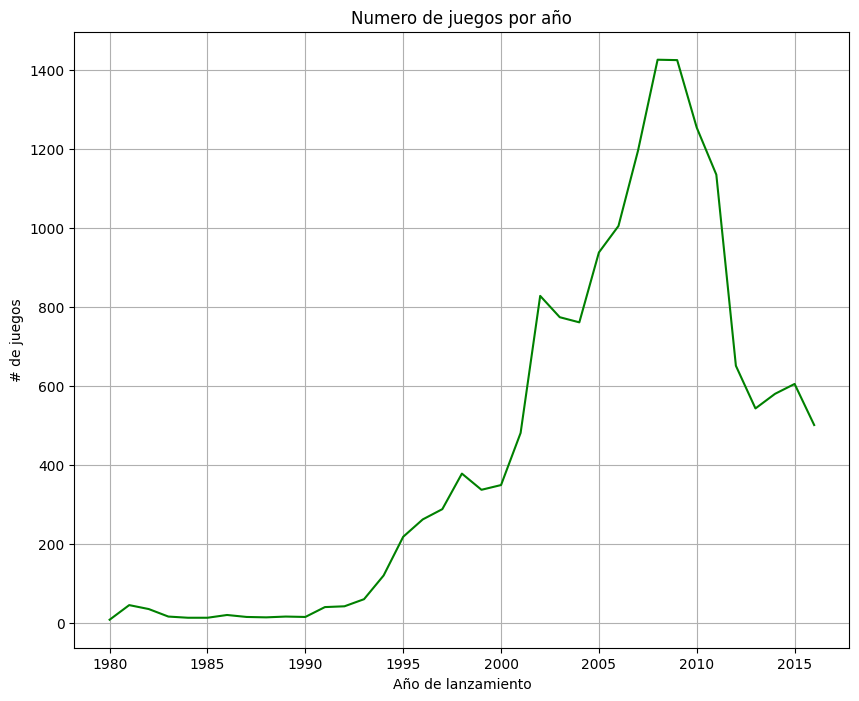

In [26]:
#Vamos a graficar de lineas
juegos_lanzados.plot(kind='line',figsize=(10,8),color='green',grid=True)
plt.title('Numero de juegos por año')
plt.xlabel('Año de lanzamiento')
plt.ylabel('# de juegos')
plt.show()

- Con los datos vistos en el grafico tenemos un aumento constante en cada año, como la tecnologia va creciendo igual lo hace este sector que crecio exponencialmente hasta el año 2008 y 2009. Ya despues del colapso financiero que se origino en esos mismos años el sector tuvo un declibe importante.

### Observa como varian las ventas de una plataforma a otra. 
- Elige las plataformas con las mayores ventas totales y construye una distribucion basada en los datos de cada año.
- Busca las plataformas que solian ser populares pero que ahora no tienen ventas.
¿. Cuanto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer.?

In [27]:
#Identificamos las plataformas con mayores ventas totales
ventas_mas = df_games.groupby(['year_of_release','platform'])['ventas_totales'].sum().sort_values(ascending=False)
print(ventas_mas.head(10))

year_of_release  platform
2004             PS2         211.81
2009             Wii         206.97
2002             PS2         205.38
2003             PS2         184.31
2008             Wii         171.32
2010             X360        170.03
1998             PS          169.49
2001             PS2         166.43
2005             PS2         160.66
2011             PS3         156.78
Name: ventas_totales, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

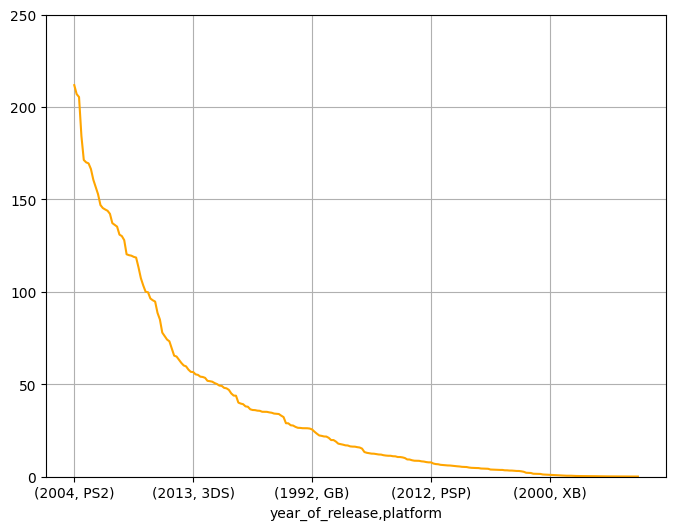

In [28]:
#hacemos un grafico de lineas para ver la distribucion anual de las ventas para las plataformas principales
ventas_mas.plot(x='year_of_release',
                y='ventas_totales',
                kind='line',
                ylim= (0,250),
                grid=True,color='orange',figsize=(8,6))
plt.show

- Vemos que playstation 2 lidera en ventas en el año 2004, seguido de Nintendo con (3DS) en el 2013

In [29]:
#Plataformas que fueron populares pero ahora no tienen ventas
plataformas_ventas_mas = df_games.groupby(['year_of_release','platform'])['ventas_totales'].sum().sort_values(ascending=False)


In [30]:
print(plataformas_ventas_mas.sort_values(ascending=False).head(20))

year_of_release  platform
2004             PS2         211.81
2009             Wii         206.97
2002             PS2         205.38
2003             PS2         184.31
2008             Wii         171.32
2010             X360        170.03
1998             PS          169.49
2001             PS2         166.43
2005             PS2         160.66
2011             PS3         156.78
2007             Wii         152.77
                 DS          146.94
2008             DS          145.31
1999             PS          144.53
2011             X360        143.84
2010             PS3         142.17
2006             Wii         137.15
1997             PS          136.17
2008             X360        135.26
2009             PS3         130.93
Name: ventas_totales, dtype: float64


In [31]:
#plataformas con menos ventas
print(plataformas_ventas_mas.sort_values().head(20))

year_of_release  platform
2007             DC          0.02
1994             3DO         0.02
1985             DS          0.02
1988             PC          0.03
1996             PCFX        0.03
2008             DC          0.04
1985             PC          0.04
1992             GG          0.04
2000             GBA         0.07
2002             N64         0.08
1995             3DO         0.08
1999             SAT         0.09
1996             NG          0.10
1994             NES         0.11
2015             PSP         0.12
1995             TG16        0.16
2008             XB          0.18
2016             Wii         0.18
1993             NG          0.21
1998             SNES        0.22
Name: ventas_totales, dtype: float64


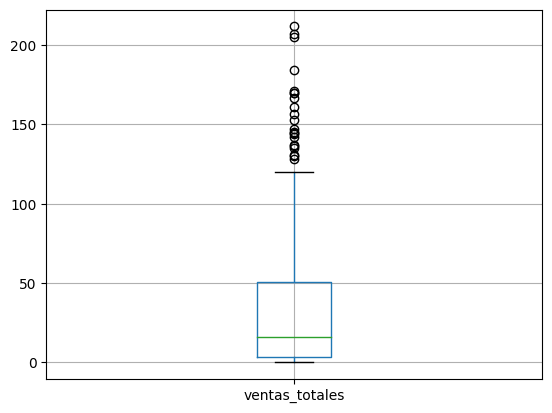

In [32]:
#haciendo grafic de boxplot
plataformas_ventas_mas.plot( y= 'ventas_totales', kind='box',grid=True)
plt.show()

- En este grafico de cajas vemos que los valores se concentran 10 y 120 y la media se encuentra en unos 45, contamos con algunos valores atipicos por arriba de 300 

### Determina para que periodo tomar datos. Para hacerlo mira tus respuestas a las preguntas anteriores. Los datos deberian permitirte construir un modelo para 2017.

- Podemos tomar los ultimos 5 o 10 años, ya que son los mas cercanos y tienen un periodo significativo para predecir los datos del año 2017

### Trabaja solo con los datos que consideres relevantes. Ignora los datos de años anteriores. 

In [33]:
#vamos a trabajar con los datos arriba de 1994, donde se ve el aumento de la demanda ignoramos los años anteriores
df_games_relevantes = df_games[df_games['year_of_release'] >= 1995]

### ¿Que plataformas son lideres de ventas.? .¿Cuales crecen y cuales se reducen.?. Elige varias plataformas potencialmente rentables. 

In [34]:
lideres_ventas = df_games_relevantes.groupby('platform')['ventas_totales'].sum().sort_values(ascending=False)
display(lideres_ventas.head(5))

platform
PS2     1233.56
X360     961.24
PS3      931.33
Wii      891.18
DS       802.76
Name: ventas_totales, dtype: float64

- Las plataformas lideres son PS2, X360, PSP, WII y DS

In [35]:
menos_ventas = df_games_relevantes.groupby('platform')['ventas_totales'].sum().sort_values()
print(menos_ventas)

platform
PCFX       0.03
3DO        0.08
TG16       0.16
NG         0.43
WS         1.42
DC        15.95
SAT       29.94
SNES      49.59
PSV       53.81
WiiU      82.19
GB       139.90
XOne     159.32
GC       196.73
N64      218.01
PC       239.79
XB       251.57
3DS      257.81
PSP      289.53
GBA      312.88
PS4      314.14
PS       721.55
DS       802.76
Wii      891.18
PS3      931.33
X360     961.24
PS2     1233.56
Name: ventas_totales, dtype: float64


- Las plataformas que menos crecen o venden son PCFX, 3D0, TG16,NG

### Crea un diagrama de caja para las ventas globales de todos los juegos, desglosados por plataforma. ¿Son significativas las diferencias en las ventas.?. ¿Que sucede con las ventas promedio en varias plataformas.?. Describe tus hallazgos. 

<function matplotlib.pyplot.show(close=None, block=None)>

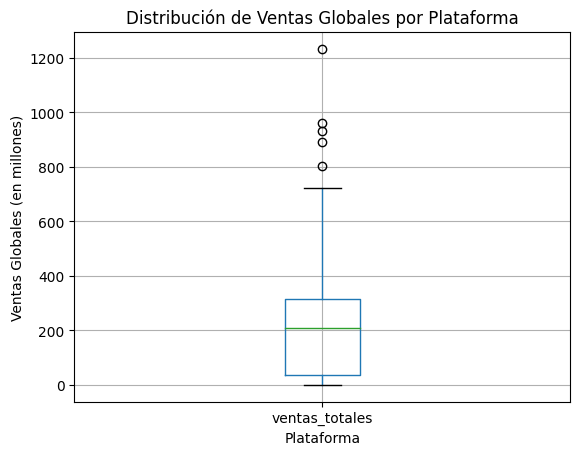

In [36]:
lideres_ventas.plot(
                     x='group_plat',
                     y='ventas_totales',kind='box',grid=True)
plt.title('Distribución de Ventas Globales por Plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Ventas Globales (en millones)')
plt.show

<div class="alert alert-block alert-success">
<b>Celdas [36]</b> <a class="tocSkip"></a><br>
La intención de graficar la distribución de ventas por plataforma es correcta, pero el gráfico de cajas (boxplot) no se genera de manera efectiva usando un `Series`. Para obtener una comparación clara entre plataformas, sería más útil construir un `DataFrame` agrupado por `group_plat` y usar `sns.boxplot()` con `x=group_plat`, `y=ventas_totales`. Esto reforzaría tus hallazgos y haría más legible la visualización.
</div>


- Las ventas se concentran con valor promedio de 210 aprox, y el conjunto de todos los datos se encuentran entre 30 y 310. Vemos 5 valores atipicos que sobresalen por arriba de 800 y 1400 

### Mira como las reseñas de usuarios y profesionales afectan las ventas de una plataforma popular (tu eleccion). Crea un grafico de dispersion y calcula la correlaccion entre las reseñas y las ventas. Saca conclusiones.

In [37]:
comentarios_critic = df_games_relevantes.groupby('critic_score')['ventas_totales'].sum().sort_values(ascending=False).head(20)
print(comentarios_critic)

critic_score
80.0    272.38
76.0    223.64
83.0    219.50
82.0    213.70
84.0    211.84
88.0    208.95
85.0    208.62
87.0    198.51
81.0    170.56
89.0    168.04
86.0    161.19
77.0    153.54
91.0    151.39
73.0    148.98
79.0    142.66
78.0    141.46
74.0    136.06
94.0    126.51
71.0    123.42
92.0    118.51
Name: ventas_totales, dtype: float64


In [38]:
comentarios_critic_score = df_games_relevantes.groupby('user_score')['ventas_totales'].sum().sort_values(ascending=False).head(20)
print(comentarios_critic_score)

user_score
80.0    313.60
79.0    250.82
85.0    237.20
82.0    224.23
87.0    218.96
86.0    218.75
78.0    216.49
84.0    216.06
83.0    200.51
77.0    192.50
81.0    181.91
89.0    177.55
75.0    171.39
76.0    169.92
74.0    153.07
90.0    145.96
88.0    134.69
73.0    133.71
63.0    128.13
66.0    118.19
Name: ventas_totales, dtype: float64


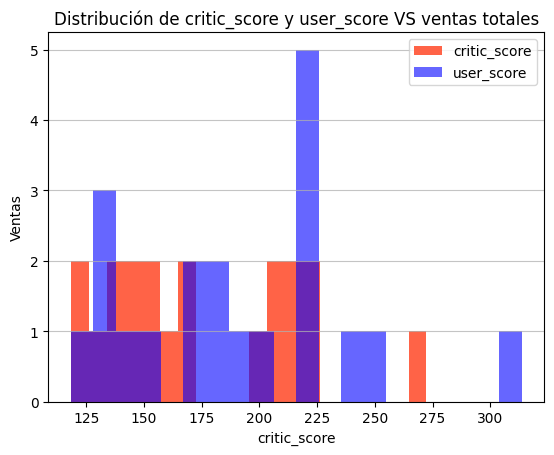

In [39]:
# Crear el histograma
plt.hist(comentarios_critic, bins=20, color='tomato',label='critic_score')
plt.hist(comentarios_critic_score, bins=20, color='blue', alpha=0.6,label='user_score')

# Añadir etiquetas y título
plt.xlabel("critic_score")
plt.ylabel("Ventas")
plt.title("Distribución de critic_score y user_score VS ventas totales")
plt.legend()

# Añadir una cuadrícula para mejor visualización
plt.grid(axis='y', alpha=0.75)

# Mostrar el histograma
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

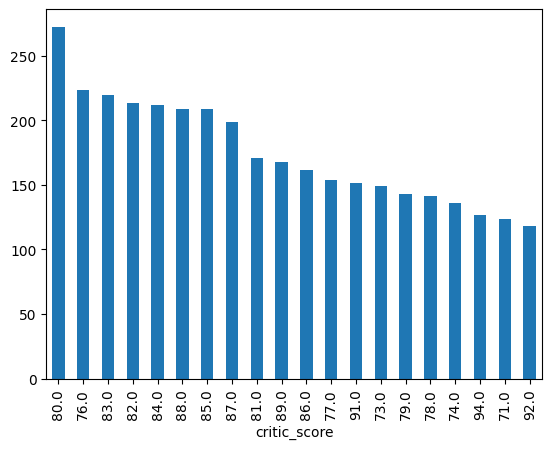

In [40]:
#Graficamos con grafico de barras las criticas de los expertos 
comentarios_critic.plot(x='critic_score', kind='bar')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

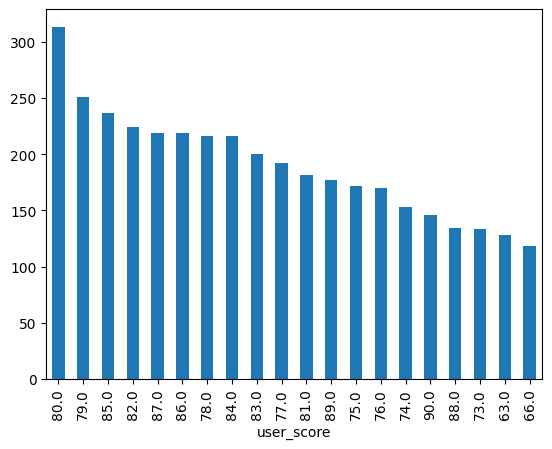

In [41]:
#Graficamos con grafico de barras las criticas de los usuarios
comentarios_critic_score.plot(x='user_score', kind='bar')
plt.show

<div class="alert alert-block alert-warning">
<b>Celdas [37–41]</b> <a class="tocSkip"></a><br>
Se intenta analizar la correlación entre críticas y ventas, pero los datos utilizados en `comentarios_critic` y `comentarios_critic_score` son agregados por puntuación, lo cual impide medir correlaciones reales a nivel de observación individual. Para hacer esta relación significativa, deberías usar directamente las columnas `critic_score` y `ventas_totales` sin agrupar previamente. De esta forma puedes usar `.corr()` o `sns.scatterplot()` y obtener un análisis más robusto.
</div>


### Teniendo en cuenta tus conclusiones compara las ventas de los mismos juegos en otras plataformas.

In [42]:
#Vamos a comparar el juego de "grand theft auto: san andreas
juegos_compara = df_games_relevantes[df_games_relevantes['name'] == 'grand theft auto: san andreas']

juegos_compara = juegos_compara[['name','platform','na_sales','eu_sales','jp_sales','other_sales','ventas_totales']]
print(juegos_compara)


                                name platform  na_sales  eu_sales  jp_sales  \
17     grand theft auto: san andreas      PS2      9.43      0.40      0.41   
865    grand theft auto: san andreas       XB      1.26      0.61      0.00   
2091   grand theft auto: san andreas       PC      0.00      0.93      0.00   
10151  grand theft auto: san andreas     X360      0.08      0.02      0.00   

       other_sales  ventas_totales  
17           10.57           20.81  
865           0.09            1.96  
2091          0.04            0.97  
10151         0.01            0.11  


- Vemos que los dos grandes gigantes de los juegos Playstation y Xbox son las plataformas que tienen mas ventas, pero en varios juegos como en Grand theft auto: san andreas tiene mas ventas la plataforma de playstation que xbox. Notamos que en las ventas de Japon las lidera playstation ya que no tienen alcance a Xbox. 

### Echa un vistazo a la distribucion general de los juegos por genero. ¿ Que se puede decir de los generos mas rentables.?. ¿ Puedes generalizar acerca de los generos con ventas altas y bajas.?. 

In [43]:
#Contamos el numero total de juegos por genero
contar_generos = df_games_relevantes['genre'].value_counts()
print(contar_generos)

Action          3222
Sports          2237
Misc            1701
Role-Playing    1434
Adventure       1280
Shooter         1247
Racing          1203
Simulation       842
Platform         808
Fighting         792
Strategy         658
Puzzle           533
Name: genre, dtype: int64


In [44]:
#Generos con mayores ventas
generos_mas_ventas = df_games_relevantes.groupby('genre')['ventas_totales'].sum().sort_values(ascending=False)
print("Ventas por genero de mayor a menor es:",generos_mas_ventas)

Ventas por genero de mayor a menor es: genre
Action          1645.07
Sports          1258.32
Shooter          967.94
Role-Playing     888.47
Misc             773.67
Racing           692.41
Platform         611.83
Fighting         402.57
Simulation       379.12
Adventure        210.25
Strategy         166.88
Puzzle           158.37
Name: ventas_totales, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

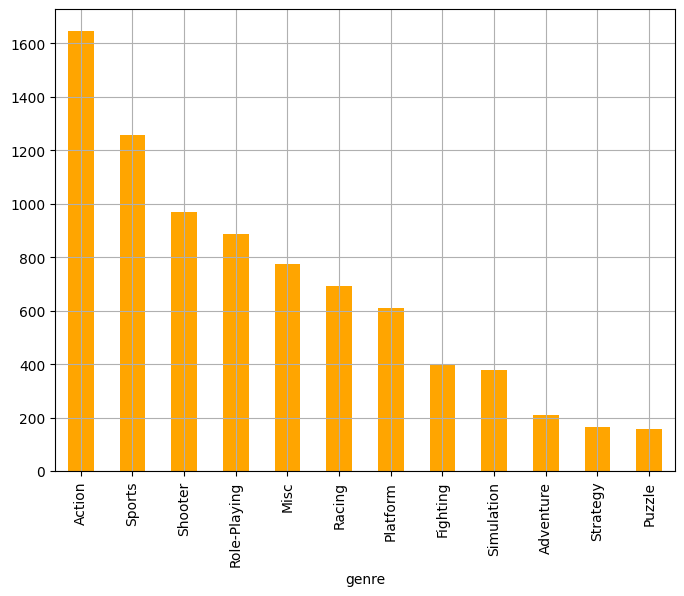

In [45]:
#Haciendo un grafico de barras para conocer la distribucion de los generos con mayores ventas
generos_mas_ventas.plot(
    x='genre',
                y='ventas_totales',
                kind='bar',
                grid=True,color='orange',figsize=(8,6))
plt.show

In [46]:
#Generos con menores ventas
generos_mas_ventas = df_games_relevantes.groupby('genre')['ventas_totales'].sum().sort_values()
print("Ventas por genero de menor a mayor:",generos_mas_ventas)

Ventas por genero de menor a mayor: genre
Puzzle           158.37
Strategy         166.88
Adventure        210.25
Simulation       379.12
Fighting         402.57
Platform         611.83
Racing           692.41
Misc             773.67
Role-Playing     888.47
Shooter          967.94
Sports          1258.32
Action          1645.07
Name: ventas_totales, dtype: float64


- Vemos que los generos con mayores ventas son Action seguido de Sports y en tercer lugar Shooter.
Y los juegos con genero de menor venta son por ultimo Puzzle, Strategy y Adventury.

## Crea un perfil de usuario para cada region (Japon, Europa y NorteAmerica)

In [47]:
perfil_NA = df_games_relevantes[df_games_relevantes['na_sales'] > 0]
plataformas_NA =  perfil_NA.groupby('group_plat')['na_sales'].sum().sort_values(ascending=False)
print(plataformas_NA.head(5))

group_plat
play        1524.49
nintendo    1502.46
xbox         870.92
pc            86.52
otros          5.98
Name: na_sales, dtype: float64


In [48]:
perfil_EU = df_games_relevantes[df_games_relevantes['eu_sales'] > 0]
plataformas_EU =  perfil_EU.groupby('group_plat')['eu_sales'].sum().sort_values(ascending=False)
print(plataformas_EU.head(5))

group_plat
play        1090.80
nintendo     721.37
xbox         379.56
pc           131.81
otros          2.11
Name: eu_sales, dtype: float64


In [49]:
perfil_JP = df_games_relevantes[df_games_relevantes['jp_sales'] > 0]
plataformas_JP = perfil_JP.groupby('group_plat')['jp_sales'].sum().sort_values(ascending=False)

print(plataformas_JP.head(5))

group_plat
nintendo    548.73
play        467.74
otros        39.57
xbox         14.02
pc            0.20
Name: jp_sales, dtype: float64


In [50]:
ventas_por_region = pd.DataFrame({
    'America': plataformas_NA,
    'Europa': plataformas_EU,
    'Japon': plataformas_JP
})

print(ventas_por_region)

            America   Europa   Japon
group_plat                          
nintendo    1502.46   721.37  548.73
otros          5.98     2.11   39.57
pc            86.52   131.81    0.20
play        1524.49  1090.80  467.74
xbox         870.92   379.56   14.02


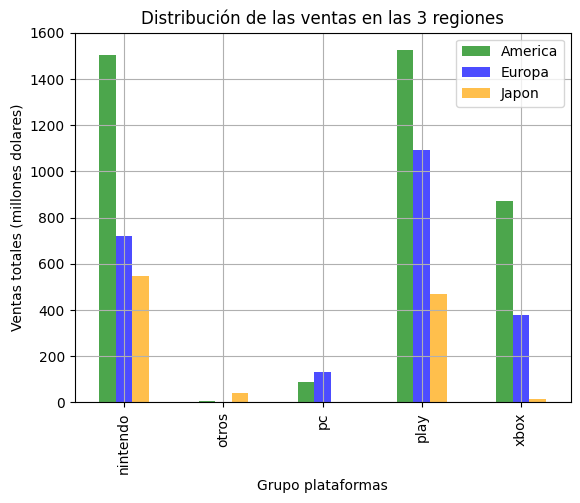

In [51]:
#Hacemos un grafico de barras para ver las diferencias de ventas entre las 3 regiones
ventas_por_region.plot(kind='bar', color={'America':'green','Europa':'blue','Japon':'orange'},label='Japon', alpha=0.7,grid=True)
# Añadir etiquetas y título
plt.xlabel("Grupo plataformas")
plt.ylabel("Ventas totales (millones dolares)")
plt.title("Distribución de las ventas en las 3 regiones")
plt.legend(loc= 'upper right')
plt.show()

- Comparando el grupo de plataformas Nintendo en las 3 regiones, vemos que tiene mas del doble de ventas que Europa y Japon es el que tiene menos ventas con 548.73 
- Comparando la Playstation America lidera las ventas con 1,524 (millones de dolares), seguido de Europa con 1,090 y al final Japon con 467
- Comparando la Xbox de nuevo America lidera con 870 y Europa con 379 y Japon solo con 14

Tenemos varios factores que pueden influir en las ventas de cada region como la poblacion, la distribucion y prohibiciones de importacion del sector de videojuegos 

### Los cinco principales genero. Explica la diferencia.

In [52]:
generos_NA =  df_games_relevantes.groupby('genre')['na_sales'].sum().sort_values(ascending=False)
generos_EU =  df_games_relevantes.groupby('genre')['eu_sales'].sum().sort_values(ascending=False)
generos_JP =  df_games_relevantes.groupby('genre')['jp_sales'].sum().sort_values(ascending=False)

print(generos_NA.head(5))
print(generos_EU.head(5))
print(generos_JP.head(5))

genre
Action     814.11
Sports     655.07
Shooter    527.59
Misc       392.43
Racing     342.82
Name: na_sales, dtype: float64
genre
Action     503.35
Sports     367.34
Shooter    308.23
Racing     230.32
Misc       208.88
Name: eu_sales, dtype: float64
genre
Role-Playing    315.17
Action          146.46
Sports          104.31
Misc             99.51
Platform         77.05
Name: jp_sales, dtype: float64


In [53]:
ventas_por_genero = pd.DataFrame({
    'America': generos_NA,
    'Europa': generos_EU,
    'Japon': generos_JP
})

print(ventas_por_genero)

              America  Europa   Japon
genre                                
Action         814.11  503.35  146.46
Adventure       91.86   56.75   45.68
Fighting       205.25   94.50   67.67
Misc           392.43  208.88   99.51
Platform       318.83  170.03   77.05
Puzzle          71.27   42.74   33.57
Racing         342.82  230.32   44.73
Role-Playing   327.55  188.08  315.17
Shooter        527.59  308.23   30.06
Simulation     177.05  111.77   59.96
Sports         655.07  367.34  104.31
Strategy        66.54   43.66   46.09


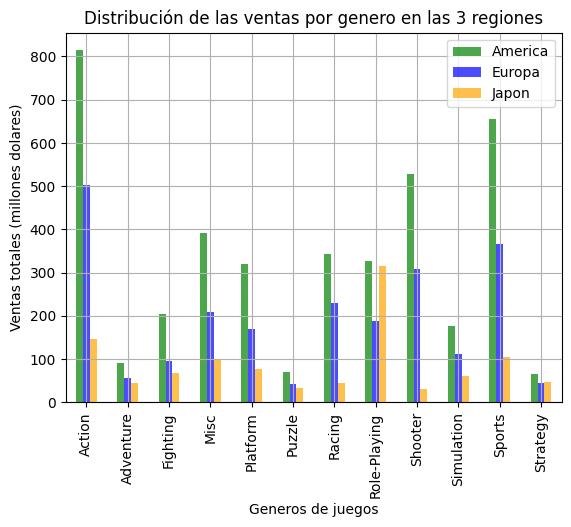

In [54]:
#Hacemos un grafico de barras para ver las diferencias de ventas por genero entre las 3 regiones
ventas_por_genero.plot(kind='bar', color={'America':'green','Europa':'blue','Japon':'orange'},label='Japon', alpha=0.7,grid=True)
# Añadir etiquetas y título
plt.xlabel("Generos de juegos")
plt.ylabel("Ventas totales (millones dolares)")
plt.title("Distribución de las ventas por genero en las 3 regiones")
plt.legend(loc= 'upper right')
plt.show()

<div class="alert alert-block alert-success">
<b>Celdas [52–54]</b> <a class="tocSkip"></a><br>
Excelente análisis comparativo por región y género. La construcción del `DataFrame` combinado para las 3 regiones, junto con el gráfico de barras apiladas, permite ver con claridad las preferencias regionales. Este tipo de visualización y segmentación agrega un valor estratégico importante para el negocio.
</div>


### Si las clasificaciones de ESRB afectan a las ventas en regiones individuales

In [55]:
#Primero vamos a ver las ventas en las 3 regiones agrupando por los ESRB por region 
#Agrupamos por rating y contamos las ventas en na_sales 
ventas_esrb_na = df_games_relevantes.groupby('rating')['na_sales'].sum().sort_values(ascending=False)
print(ventas_esrb_na)

rating
E       1274.24
T        747.19
M        742.87
E10+     345.50
K-A        2.56
EC         1.53
AO         1.26
RP         0.00
Name: na_sales, dtype: float64


- Notamos que las ventas por clasificación en America esta liderada por la clasificacion E(Para todos), seguido por T(Adolesentes) y M(Maduro).

In [56]:
#Agrupamos por rating y sumamos las ventas en europa
ventas_esrb_eu = df_games_relevantes.groupby('rating')['eu_sales'].sum().sort_values(ascending=False)
print(ventas_esrb_eu)

rating
E       703.86
M       480.00
T       420.73
E10+    183.33
AO        0.61
K-A       0.27
EC        0.11
RP        0.03
Name: eu_sales, dtype: float64


In [57]:
#Agrupamos por rating y sumamos las ventas en japon
ventas_esrb_jp = df_games_relevantes.groupby('rating')['jp_sales'].sum().sort_values(ascending=False)
print(ventas_esrb_jp)

rating
E       197.96
T       150.17
M        63.58
E10+     40.20
K-A       1.46
AO        0.00
EC        0.00
RP        0.00
Name: jp_sales, dtype: float64


In [58]:
#hacemos un df con las 3 ventas agrupados por rating de cada region
ventas_por_esrb = pd.DataFrame({
    'America': ventas_esrb_na,
    'Europa': ventas_esrb_eu,
    'Japon': ventas_esrb_jp
})

print(ventas_por_esrb)

        America  Europa   Japon
rating                         
AO         1.26    0.61    0.00
E       1274.24  703.86  197.96
E10+     345.50  183.33   40.20
EC         1.53    0.11    0.00
K-A        2.56    0.27    1.46
M        742.87  480.00   63.58
RP         0.00    0.03    0.00
T        747.19  420.73  150.17


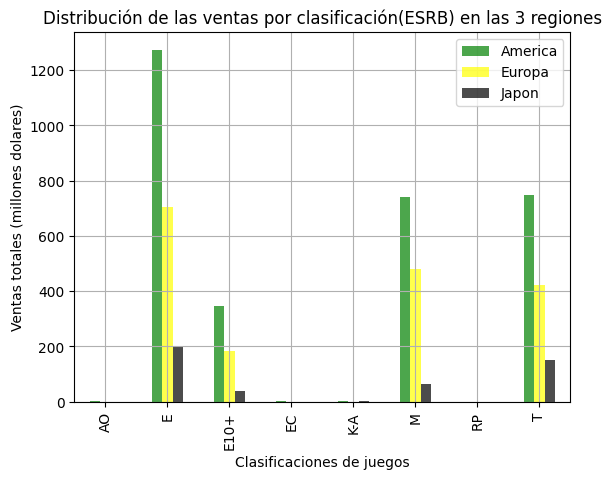

In [59]:
#Hacemos un grafico de barras para ver las diferencias de ventas por clasificacion entre las 3 regiones
ventas_por_esrb.plot(kind='bar', color={'America':'green','Europa':'yellow','Japon':'black'},label='Japon', alpha=0.7,grid=True)
# Añadir etiquetas y título
plt.xlabel("Clasificaciones de juegos")
plt.ylabel("Ventas totales (millones dolares)")
plt.title("Distribución de las ventas por clasificación(ESRB) en las 3 regiones")
plt.legend(loc= 'upper right')
plt.show()

- Como conclusion opino que las clasificaciones no definen las ventas entre las 3 regiones, ya que se ve la misma tendencia de ventas para los 3 principales clasificaciones E, M y T. 
- Analizando la clasificación de E(Para todos), es la clasificacion mas vendida en las 3 regiones.
- La segunda clasificacion con mas ventas esta casi enpatada entre T(Adolesentes) y M(Maduro) esto en las regiones de America y Europa

## Prueba de hipótesis.

<div class="alert alert-block alert-warning">
<b>Celdas [hipótesis]</b> <a class="tocSkip"></a><br>
Las pruebas de hipótesis están correctamente formuladas y ejecutadas, pero sería más sólido declarar explícitamente las hipótesis nula y alternativa antes de la prueba t. Por ejemplo:  
H₀: Las calificaciones promedio entre XOne y PC son iguales.  
H₁: Las calificaciones promedio entre XOne y PC son diferentes.  
Esto fortalece el rigor del análisis estadístico y lo hace más comprensible para audiencias no técnicas.
</div>


### Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas. 

In [60]:
#segmentamos la plataforma Xbox one y PC
xone = df_games_relevantes[df_games_relevantes['platform'] == 'XOne']['user_score']
pc = df_games_relevantes[df_games_relevantes['platform'] == 'PC']['user_score']

xone_prom = xone.mean()
pc_prom = pc.mean()
print(f"Las calificaciones promedio de Xbox One es:{xone_prom:.2f}")
print(f"Las calificaciones promedio de PC es:{pc_prom:.2f}")


Las calificaciones promedio de Xbox One es:65.21
Las calificaciones promedio de PC es:70.73


In [61]:
alpha = 0.05 # el nivel de significancia estadística crítica
# si el valor p es menor que alpha, rechazamos la hipótesis

results = st.ttest_ind(xone,pc,nan_policy='omit')
print('valor p: ',results.pvalue*100,'%') # extraer el valor p

if (results.pvalue < alpha): # compara el valor p con el umbral alpha
    print('Rechazamos la hipótesis nula')
else: 
    print("No podemos rechazar la hipótesis nula")

valor p:  0.0009379956219355572 %
Rechazamos la hipótesis nula


- Como conclusion vemos que el valor de P es muy pequeño y por esto rechazamos la hipotesis nula ya que son diferentes los valoes promedios de xbox y pc

### — Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

In [62]:
#segmentamos la plataforma por el genero Action y Sports
accion= df_games_relevantes[df_games_relevantes['genre'] == 'Action']['user_score']
sports= df_games_relevantes[df_games_relevantes['genre'] == 'Sports']['user_score']

accion_prom = accion.mean()
sports_prom = sports.mean()
print(f"Las calificaciones promedio del genero Action es:{accion_prom:.2f}")
print(f"Las calificaciones promedio del genero Sports es:{sports_prom:.2f}")
print()
alpha = 0.05 # el nivel de significancia estadística crítica
# si el valor p es menor que alpha, rechazamos la hipótesis

results = st.ttest_ind(accion,sports,nan_policy='omit')
print('valor p: ',results.pvalue*100,'%') # extraer el valor p

if (results.pvalue < alpha): # compara el valor p con el umbral alpha
    print('Rechazamos la hipótesis nula')
else: 
    print("No podemos rechazar la hipótesis nula")


Las calificaciones promedio del genero Action es:70.58
Las calificaciones promedio del genero Sports es:69.53

valor p:  6.8336865038826 %
No podemos rechazar la hipótesis nula


- el valor de P es mas grande que el umbra de alpha, entonces No poedemos rechazar la hipotesis nula 

### Explica:

— Cómo formulaste las hipótesis nula y alternativa.

- La hipotesis que se utilizo fue la prueba t de Student, donde se compara dos muestras independientes, en este caso se comparo el promedio de puntuaciones de usuarios entre los juegos de PC y los juegos de Xbox, se establecio el umbral de 0.05 %. Esta hipotesis el resultado nos dio que rechazamos la hipotesis nula ya que el valor de p resulto demasiado pequeño que el valor umbral de 0.5. Con esto tenemos que las calificaciones promedio de los usuarios de xone y pc son diferentes.

— Qué criterio utilizaste para probar las hipótesis y por qué.

- El criterio que se utilizo fue usando esta formula estadistica de la prueba t ya que se tenian que comparar dos grupos independientes de valores tanto para las plataformas y generos que se plantearon en las hipotesis-
- Para el caso de la segunda hipotesis donde las calificaciones de los usuarios por genero accion y deportes se encontro que el valor de p  es mayor que umbral de alpha por esta razon arrojo la hipotesis alterna que dice que No podemos rechazar la hiportesis nula. En este caso las calificaciones promedio entre ambos generos resulto ser muy parecidas casi iguales. 

## Conclusión general.

- Como conclusion tenemos que si es posible determinar si un juego de video puede ser rentable o no en base a una serie de datos recopilados por las ventas, los generos, las plataforma, las calificaciones o puntuaciones emitidas por los mismos jugadores y expertos.
- Se realizaron varias preguntas de negocio en el analisis de los datos como cuantos juegos fueron lanzados en determinados años para con esto conocer la tendencia el aumento o disminucion de los mismos, tambien de conocer en que plataformas se venden mas juegos y en cual de las 3 regiones que se compararon venden mas juegos, se analizo tambien las 5 plataformas mas vendidas y se conocio los generos mas jugados.
-  Se realizaron dos analisis de hipotesis preguntandonos si las calificaciones o puntuacion de los usuarios para 2 plataformas eran las mismas y si las puntuaciones de 2 generos eran diferentes.
- En conclusion del paso 1: Primero se analizaron y estudiaron los datos que venian en el DF para conocerlos y entender el contenido de las columnas y filas y si no se entendia se investiga el significado.
- En conclusion del paso 2: Aquí ya se comenzo a trabajar o preparar los datos para dejarlos limpios se realizo snake cases en las filas y columnas se reemplazaron los nombres de las columnas a minusculas, tambien se convirtieron los tipos de datos necesarios a otro tipo de dato adecuado para el analisis posterior.
- En conclusion del paso 3: En esta parte ya comenzamos a realizar el analisis de datos y se resolvieron algunas preguntas planteadas por el negocio se realizaron segmetaciones de datos, comparaciones y al final se mostraron los datos con graficos de lineas, barras, cajon de bigotes, dispersion e histogramas.

<div class="alert alert-block alert-success">
<b>Comentario final</b> <a class="tocSkip"></a><br>
¡Muy bien hecho, Luis! Tu proyecto muestra un análisis completo, con transformaciones justificadas, segmentación inteligente y visualizaciones útiles. Has demostrado capacidad tanto técnica como analítica.  

Sigue así, tu progreso es evidente y prometedor. ¡Felicidades!
</div>
